# Лабораторная работа №1 — Вариант V=12

Горбунов Сергей Михайлович - студент группы Б24-507

Импорт библиотек

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random
from typing import List, Tuple

D = 5                     # размерность (V=12 -> d = 5 + (12 mod 6) = 5)
LOWER_BOUND = -500.0
UPPER_BOUND = 500.0

# Функция приспособленности

## Что именно мы оптимизируем?

Функция Цин (вариант V=12):

$$
f(x) = \sum_{i=1}^{5} (x_i^2 - i)^2
$$

**Свойства:**
- Глобальный минимум `f* = 0` достигается в точках $x_i = \pm\sqrt{i}$.
- Функция **многоэкстремальная**: у неё много локальных минимумов,
  «разбросаных» по всей области `[-500, 500]^5`.
- Пространство поиска **огромное**: 5 измерений, каждая координата от −500 до 500.

**Почему это сложно для простых методов?**
- Локальный поиск застрянет в первом же локальном минимуме.
- Случайный поиск при 10 000 точек даст результат порядка $10^7$, что
  на 17 порядков хуже глобального минимума.
- Полный перебор невозможен: $1000^5 = 10^{15}$ точек.

In [12]:
def fitness(x: np.ndarray) -> float:
    """Функция Цин: f(x) = sum_{i=1}^d (x_i^2 - i)^2"""
    return np.sum((x**2 - np.arange(1, D+1))**2)

Класс особи

In [13]:
class Individual:
    def __init__(self, genes: np.ndarray):
        self.genes = genes
        self.fitness = fitness(genes)

Инициализация популяции

In [14]:
def init_population(pop_size):
    pop = []
    for _ in range(pop_size):
        genes = np.random.uniform(LOWER_BOUND, UPPER_BOUND, D)
        pop.append(Individual(genes))
    return pop

Селекция (турнирная)

Выбирается лучшая особь из случайных
k участников турнира. Давление селекции регулируется размером турнира.

In [15]:
def tournament_selection(pop: List[Individual], k: int = 3) -> Individual:
    """Турнирная селекция"""
    selected = random.sample(pop, k)
    return min(selected, key=lambda ind: ind.fitness)

Кроссинговер BLX-α

BLX-α расширяет интервал между родителями на долю α, обеспечивая исследование пространства

In [16]:
def blx_alpha_crossover(p1: Individual, p2: Individual, alpha: float = 0.5) -> Tuple[Individual, Individual]:
    """BLX-alpha кроссинговер для вещественных векторов"""
    child1_genes = np.empty(D)
    child2_genes = np.empty(D)
    for i in range(D):
        c_min = min(p1.genes[i], p2.genes[i])
        c_max = max(p1.genes[i], p2.genes[i])
        d = c_max - c_min
        low = c_min - alpha * d
        high = c_max + alpha * d
        child1_genes[i] = np.random.uniform(low, high)
        child2_genes[i] = np.random.uniform(low, high)
    # Ограничение границами
    child1_genes = np.clip(child1_genes, LOWER_BOUND, UPPER_BOUND)
    child2_genes = np.clip(child2_genes, LOWER_BOUND, UPPER_BOUND)
    return Individual(child1_genes), Individual(child2_genes)

Мутация

Вероятность мутации задаётся параметром mutation_rate, а сила мутации (СКО) линейно уменьшается от sigma0 до 1. Это реализует дополнительное задание.

In [17]:
def mutate(ind: Individual, generation: int, max_generations: int, mutation_rate: float, sigma0: float):
    """Гауссова мутация с адаптивным масштабом (уменьшается со временем)"""
    # Адаптивный масштаб: от sigma0 до 1
    sigma = sigma0 * (1 - generation / max_generations) + 1.0
    for i in range(D):
        if random.random() < mutation_rate:
            ind.genes[i] += np.random.normal(0, sigma)
    ind.genes = np.clip(ind.genes, LOWER_BOUND, UPPER_BOUND)
    ind.fitness = fitness(ind.genes)

Основной цикл генетического алгоритма

Классический поколенческий ГА с элитизмом. Возвращает историю лучшего значения и лучшую особь.

In [18]:
def run_ga(seed: int, pop_size: int = 50, generations: int = 200,
           crossover_rate: float = 0.8, mutation_rate: float = 0.1,
           sigma0: float = 50.0) -> Tuple[List[float], Individual]:
    """Запуск ГА. Возвращает историю лучшего фитнеса по поколениям и лучшую особь."""
    random.seed(seed)
    np.random.seed(seed)
    pop = init_population(pop_size)
    best_ind = min(pop, key=lambda ind: ind.fitness)
    best_history = [best_ind.fitness]

    for gen in range(generations):
        new_pop = []
        # Элитизм: сохраняем лучшую особь
        new_pop.append(Individual(best_ind.genes.copy()))
        while len(new_pop) < pop_size:
            # Селекция
            p1 = tournament_selection(pop)
            p2 = tournament_selection(pop)
            # Кроссинговер
            if random.random() < crossover_rate:
                c1, c2 = blx_alpha_crossover(p1, p2)
            else:
                c1, c2 = Individual(p1.genes.copy()), Individual(p2.genes.copy())
            # Мутация
            mutate(c1, gen, generations, mutation_rate, sigma0)
            mutate(c2, gen, generations, mutation_rate, sigma0)
            new_pop.append(c1)
            if len(new_pop) < pop_size:
                new_pop.append(c2)
        pop = new_pop
        # Обновление лучшей особи
        current_best = min(pop, key=lambda ind: ind.fitness)
        if current_best.fitness < best_ind.fitness:
            best_ind = Individual(current_best.genes.copy())
        best_history.append(best_ind.fitness)
    return best_history, best_ind

Одиночный запуск

In [19]:
hist, best = run_ga(seed=42, pop_size=50, generations=200,
                    crossover_rate=0.8, mutation_rate=0.1, sigma0=50.0)
print(f"Лучшее значение: {best.fitness:.6e}")
print(f"Лучшие гены: {best.genes}")
print(f"Целевые гены (sqrt(i)): {np.sqrt(np.arange(1, D+1))}")

Лучшее значение: 2.882057e-12
Лучшие гены: [ 0.99999961  1.41421379 -1.73205075  2.0000003  -2.23606785]
Целевые гены (sqrt(i)): [1.         1.41421356 1.73205081 2.         2.23606798]


Запуск серии из 20 независимых экспериментов

Проводится 20 запусков с разными seed. Сохраняются истории сходимости и лучшие значения

In [20]:
n_runs = 20
generations = 200
pop_size = 50
histories = []
best_solutions = []

print("=" * 55)
print("Серия из 20 независимых запусков")
print("=" * 55)
for i in range(n_runs):
    seed = 1000 + i
    hist, best_ind = run_ga(seed, pop_size=pop_size, generations=generations,
                            crossover_rate=0.8, mutation_rate=0.1, sigma0=50.0)
    histories.append(hist)
    best_solutions.append(best_ind.fitness)
    print(f"Запуск {i+1:2d}: лучшее = {best_ind.fitness:.6e}")

best_solutions = np.array(best_solutions)
histories = np.array(histories)
print("\n✅ Серия завершена")

Серия из 20 независимых запусков
Запуск  1: лучшее = 9.802449e-06
Запуск  2: лучшее = 3.675042e-06
Запуск  3: лучшее = 1.577316e-06
Запуск  4: лучшее = 3.545430e-09
Запуск  5: лучшее = 3.399341e-08
Запуск  6: лучшее = 2.253198e-06
Запуск  7: лучшее = 2.123553e-07
Запуск  8: лучшее = 8.792095e-10
Запуск  9: лучшее = 7.113521e-07
Запуск 10: лучшее = 5.086671e-09
Запуск 11: лучшее = 1.792036e-05
Запуск 12: лучшее = 8.631591e-06
Запуск 13: лучшее = 1.521982e-09
Запуск 14: лучшее = 3.461190e-09
Запуск 15: лучшее = 8.510170e-11
Запуск 16: лучшее = 1.026522e-08
Запуск 17: лучшее = 6.628738e-07
Запуск 18: лучшее = 3.654489e-07
Запуск 19: лучшее = 2.196084e-07
Запуск 20: лучшее = 2.430643e-05

✅ Серия завершена


Статистический анализ результатов

Вычисляются основные статистики: минимум, среднее, медиана, стандартное отклонение, максимум.

In [21]:
print(f"Лучшее:      {np.min(best_solutions):.6e}")
print(f"Среднее:     {np.mean(best_solutions):.6e}")
print(f"Медиана:     {np.median(best_solutions):.6e}")
print(f"Ст. откл.:   {np.std(best_solutions):.6e}")
print(f"Худшее:      {np.max(best_solutions):.6e}")

Лучшее:      8.510170e-11
Среднее:     3.519843e-06
Медиана:     2.925286e-07
Ст. откл.:   6.545963e-06
Худшее:      2.430643e-05


Визуаллизация сходимости

Строится график средней траектории, минимума, максимума и доверительного коридора (±1 СКО). Логарифмическая шкала по Y.

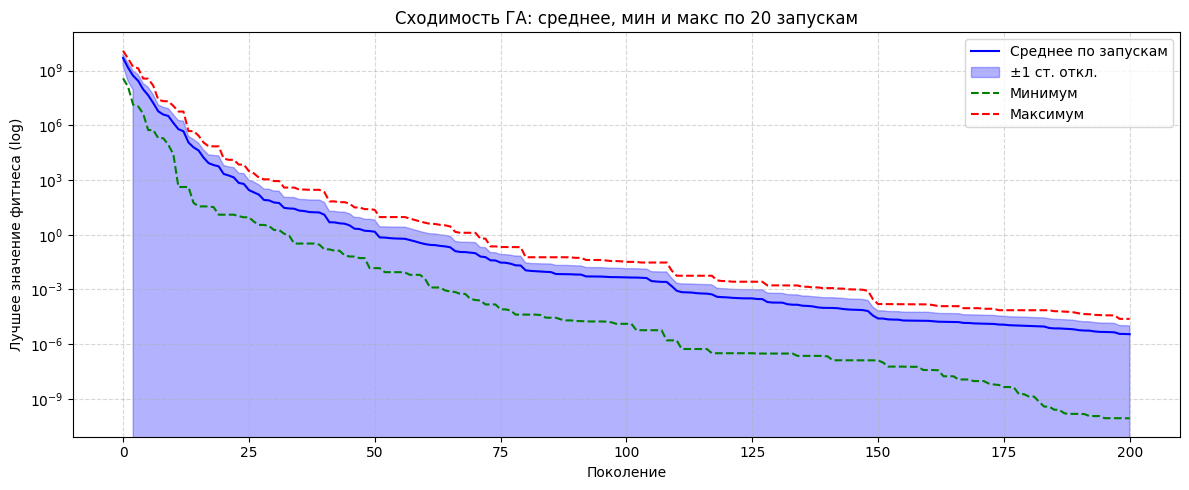

In [22]:
mean_hist = np.mean(histories, axis=0)
min_hist = np.min(histories, axis=0)
max_hist = np.max(histories, axis=0)
std_hist = np.std(histories, axis=0)

plt.figure(figsize=(12, 5))
plt.plot(mean_hist, label='Среднее по запускам', color='blue')
plt.fill_between(range(len(mean_hist)), mean_hist - std_hist, mean_hist + std_hist,
                 alpha=0.3, color='blue', label='±1 ст. откл.')
plt.plot(min_hist, label='Минимум', color='green', linestyle='--')
plt.plot(max_hist, label='Максимум', color='red', linestyle='--')
plt.yscale('log')
plt.xlabel('Поколение')
plt.ylabel('Лучшее значение фитнеса (log)')
plt.title('Сходимость ГА: среднее, мин и макс по 20 запускам')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('convergence_20runs.png', dpi=120)
plt.show()

 Сравнение двух конфигураций (вероятность мутации)

 Сравниваются две вероятности мутации: 0.05 и 0.2. Показывается влияние на среднее, медиану и лучшее значение.

In [23]:
configs = [0.05, 0.2]
results_config = {}
for mr in configs:
    best_vals = []
    for i in range(n_runs):
        seed = 2000 + i
        _, best_ind = run_ga(seed, pop_size=50, generations=200,
                             crossover_rate=0.8, mutation_rate=mr, sigma0=50.0)
        best_vals.append(best_ind.fitness)
    results_config[mr] = np.array(best_vals)
    print(f"mutation_rate={mr}:")
    print(f"   среднее = {np.mean(best_vals):.6e}")
    print(f"   медиана = {np.median(best_vals):.6e}")
    print(f"   лучшее  = {np.min(best_vals):.6e}")
    print(f"   худшее  = {np.max(best_vals):.6e}")

mutation_rate=0.05:
   среднее = 3.866778e-03
   медиана = 2.374081e-05
   лучшее  = 1.612129e-12
   худшее  = 3.307022e-02
mutation_rate=0.2:
   среднее = 5.587272e-01
   медиана = 4.983440e-01
   лучшее  = 1.542580e-01
   худшее  = 1.105153e+00


Сравнение со случайным поиском

При том же бюджете вычислений (10 000) случайный поиск даёт значительно худший результат, что обосновывает применение ГА.

In [24]:
budget = pop_size * generations  # 10 000 вычислений
random.seed(777)
np.random.seed(777)
random_best = np.inf
for _ in range(budget):
    x = np.random.uniform(LOWER_BOUND, UPPER_BOUND, D)
    val = fitness(x)
    if val < random_best:
        random_best = val

print(f"Бюджет вычислений: {budget}")
print(f"Случайный поиск: лучшее = {random_best:.6e}")
print(f"ГА (лучшее из 20): {np.min(best_solutions):.6e}")
print(f"Преимущество ГА: в {random_best / np.min(best_solutions):.1f} раз лучше")

Бюджет вычислений: 10000
Случайный поиск: лучшее = 1.841967e+07
ГА (лучшее из 20): 8.510170e-11
Преимущество ГА: в 216443086750953376.0 раз лучше
